In [1]:
import networkx as nx
from  TP_Astar_M2.GED_lib import (graph_loader,path_Dijkstra,
                     draw_pair_graph,make_pair_tree,
                     draw_tree,draw_path,from_leaf_to_path)

In [2]:
g1_toy = nx.Graph()
g1_toy.add_node(0,node_label = "O")
g1_toy.add_node(1,node_label = "C")
g1_toy.add_node(2,node_label = "O")
g1_toy.add_node(3,node_label = "N")
g1_toy.add_edge(0,1,edge_label = 1)
g1_toy.add_edge(1,2,edge_label = 1)
g1_toy.add_edge(2,3,edge_label = 2)
g1_toy.add_edge(3,1,edge_label = 2)

g2_toy = nx.Graph()
g2_toy.add_node(0,node_label = "N")
g2_toy.add_node(1,node_label = "C")
g2_toy.add_node(2,node_label = "C")
g2_toy.add_edge(0,1,edge_label = 1)
g2_toy.add_edge(1,2,edge_label = 2)

(<Axes: >, <Axes: >)

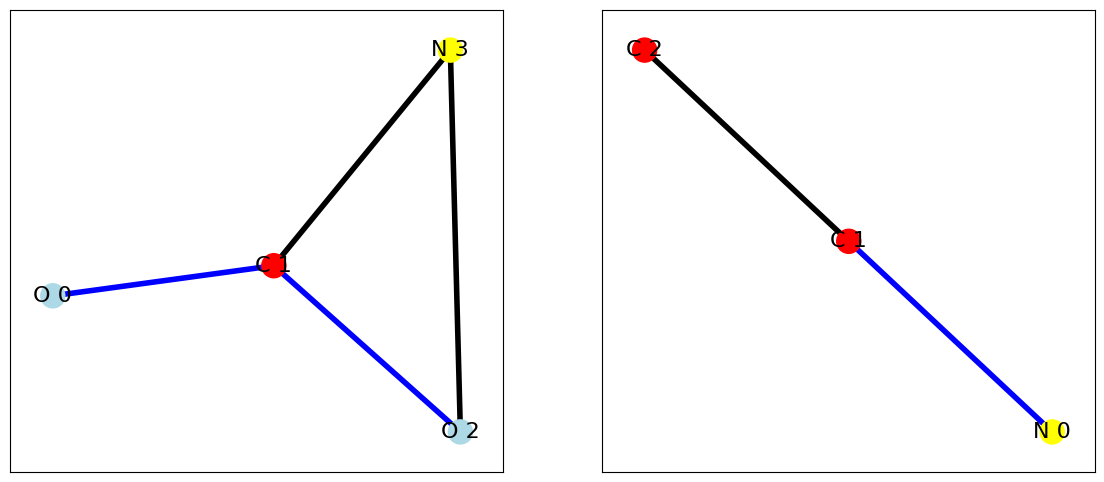

In [3]:
draw_pair_graph(g1_toy,g2_toy)

In [16]:
# Only count the number of vertices for each possible label value (slide 23)
def count_vertice_label(g):
    labels=set([v[1]['node_label'] for v in g.nodes.data()])
    res={i:0 for i in labels}
    for i in range(len(g.nodes)):
        label= g.nodes.get(i)['node_label']
        res[label]+=1
    return res

In [25]:
# Add the number of edges with two specific labels at end vertices (slide 24)
def count_vertice_edge(g):
    labels=set([v[2]['edge_label'] for v in g.edges.data()])
    res={i:0 for i in labels}
    for i in list(g.edges.data()):
        label= i[2]['edge_label']
        res[label]+=1
    return res

In [24]:
count_vertice_label(g1_toy)

{'N': 1, 'O': 2, 'C': 1}

In [7]:
count_vertice_label(g2_toy)

{'N': 1, 'O': 0, 'C': 2}

In [8]:
count_vertice_edge(g1_toy)

{1: 2, 2: 2}

In [9]:
count_vertice_edge(g2_toy)

{1: 1, 2: 1}

In [55]:
#Graph probing (add the count for edge structures) (slide 26)

def edge_struct(g):
    my_dict=count_vertice_label(g)
    for struct in list(g1_toy.edges(data=True)):
        if struct not in  list(my_dict.keys()):
            my_dict[struct]=0
        else:
            my_dict[struct]+=0
    return my_dict


In [56]:
edge_struct(g1_toy)

TypeError: unhashable type: 'dict'

In [48]:
[v for v in g1_toy.edges.data()]

[(0, 1, {'edge_label': 1}),
 (1, 2, {'edge_label': 1}),
 (1, 3, {'edge_label': 2}),
 (2, 3, {'edge_label': 2})]

In [38]:
s={1:2,'a':2}
if 3 in s.keys():
    print('souna')
    

In [52]:
list(g1_toy.edges(data=True))

[(0, 1, {'edge_label': 1}),
 (1, 2, {'edge_label': 1}),
 (1, 3, {'edge_label': 2}),
 (2, 3, {'edge_label': 2})]